# The Appetite Gauge \U0001F321
### When the racy stocks lead, is the market telling you something — or telling you it went up?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

Split the S&P into its riskiest and its calmest halves, watch the ratio, and you have the
oldest risk-appetite gauge on a trading desk. There is one problem with reading it as a
warning system, and it is arithmetic rather than opinion: the spread is roughly a
half-leveraged bet on the index.

> \U0001F4D3 **This is the plain-language layer.** The beta-neutralisation, the HAC grid and
> the multiple regression are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is the gauge really a risk-appetite measure? | Partly. Most of its variance is the market itself. |
| Does the raw gauge predict the market? | Weakly, and no better than the market's own trend does. |
| Does the beta-neutral residual predict it? | Not measurably, in fifteen years of data. |
| Is the risk-on rule worth running? | It trades return for a shallower drawdown — the same bargain any trend filter offers. |

## 1 · The claim

> *"Watch high beta versus low vol. When the ratio rolls over, the market is losing its nerve —
> and price follows."*

The mechanism is plausible: appetite for risk should show up in the cross-section before it
shows up in the index. The measurement is where it gets difficult.

In [2]:
from appetite import data, strategy as st

px = data.load_prices()
rets = st.to_returns(px)
common = rets[list(data.TICKERS)].dropna()
sig = st.build_signals(common, data.HIGH_BETA, data.LOW_VOL, data.MARKET)
sb = st.spread_beta(common, data.HIGH_BETA, data.LOW_VOL, data.MARKET)
print(f"as-of {data.AS_OF} | {common.index[0].date()} -> {common.index[-1].date()} "
      f"({len(common) / 252:.1f} years)")
print(f"beta of {data.HIGH_BETA}: {sb['beta_high']:+.2f}   "
      f"beta of {data.LOW_VOL}: {sb['beta_low']:+.2f}   "
      f"beta of the spread: {sb['beta_of_spread']:+.2f}   R2 on the market: "
      f"{sb['r2_on_market']:.0%}")

as-of 2026-06-30 | 2011-06-02 -> 2026-06-30 (15.0 years)
beta of SPHB: +1.42   beta of SPLV: +0.68   beta of the spread: +0.74   R2 on the market: 35%


Note the third number. A spread whose beta is +0.6 is not a thermometer, it is a position.

## 2 · The confound, in one chart

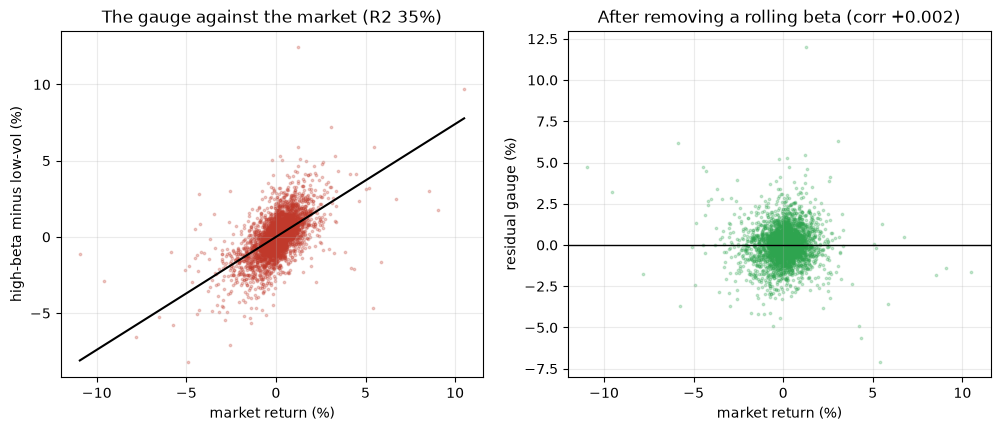

In [3]:
spread = sig["raw"].dropna()
m = common[data.MARKET].reindex(spread.index)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(m * 100, spread * 100, s=3, alpha=0.25, color="#c0392b")
xs = np.linspace(m.min(), m.max(), 50)
axes[0].plot(xs * 100, sb["beta_of_spread"] * xs * 100, color="k", lw=1.5)
axes[0].set_xlabel("market return (%)"); axes[0].set_ylabel("high-beta minus low-vol (%)")
axes[0].set_title(f"The gauge against the market (R2 {sb['r2_on_market']:.0%})")
neutral = sig["beta_neutral"].dropna()
mm = common[data.MARKET].reindex(neutral.index)
axes[1].scatter(mm * 100, neutral * 100, s=3, alpha=0.25, color="#2ea44f")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("market return (%)"); axes[1].set_ylabel("residual gauge (%)")
axes[1].set_title(f"After removing a rolling beta (corr {neutral.corr(mm):+.3f})")
plt.show()

> \U0001F52C **For the quants.** The left panel is what the desk is watching. The right panel is
> what is left once you stop double-counting the market — and it is the only thing that could
> possibly be new information.

## 3 · Does either version predict?

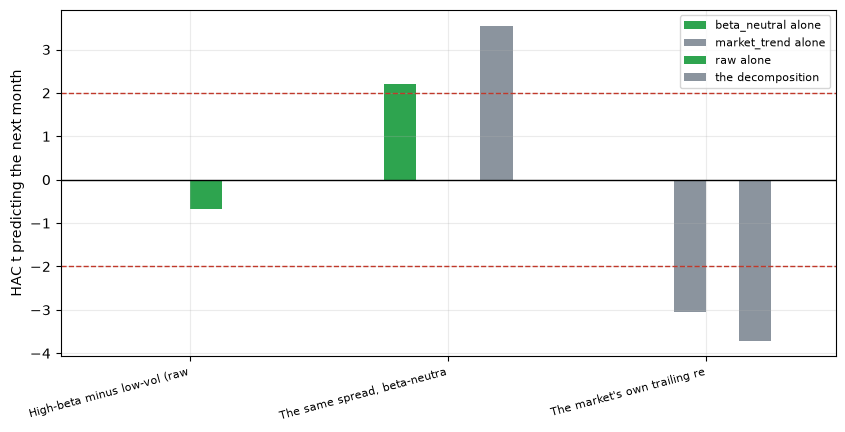

'     specification       signal     beta       t     r2\n         raw alone          raw  -1.0998 -0.6843 0.0018\nbeta_neutral alone beta_neutral   3.8679  2.2052 0.0131\nmarket_trend alone market_trend  -9.2669 -3.0405 0.0469\n the decomposition beta_neutral   6.4710  3.5535 0.0800\n the decomposition market_trend -11.7739 -3.7067 0.0800'

In [4]:
race = st.horse_race(sig, common[data.MARKET], lookback=63, horizon=21)
fig, ax = plt.subplots(figsize=(10, 4.5))
piv = race.pivot(index="signal", columns="specification", values="t")
piv = piv.reindex(list(st.SIGNALS))
piv.index = [st.SIGNAL_LABEL[i][:28] for i in piv.index]
piv.plot.bar(ax=ax, color=["#2ea44f", "#8b949e"])
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, ls="--", color="#c0392b", lw=1)
ax.set_ylabel("HAC t predicting the next month"); ax.legend(title="", fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
plt.show()
race.round(4).to_string(index=False)

## 4 · The rule

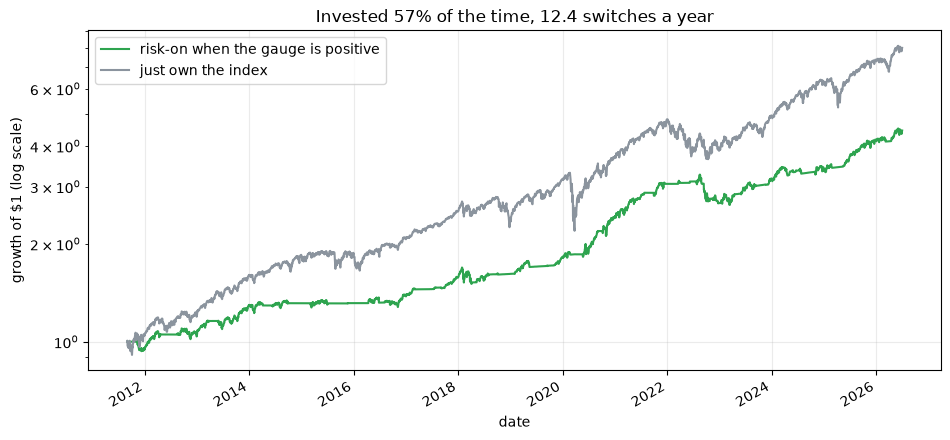

rule  CAGR +10.63%  Sharpe +1.11  maxDD -19.4%
index CAGR +15.10%  Sharpe +0.92  maxDD -33.7%


In [5]:
r = st.timing_rule(common, sig["raw"], data.MARKET, data.CASH, lookback=63, cost_bps=2.0)
curves = pd.DataFrame({
    "risk-on when the gauge is positive": (1 + r["returns"]).cumprod(),
    "just own the index": (1 + common[data.MARKET].reindex(r["returns"].index)).cumprod(),
})
fig, ax = plt.subplots(figsize=(11, 5))
curves.plot(ax=ax, logy=True, color=["#2ea44f", "#8b949e"])
ax.set_ylabel("growth of $1 (log scale)"); ax.legend(title="")
ax.set_title(f"Invested {r['time_invested']:.0%} of the time, "
             f"{r['switches_per_year']:.1f} switches a year")
plt.show()
print(f"rule  CAGR {r['strategy']['cagr']:+.2%}  Sharpe {r['strategy']['sharpe']:+.2f}  "
      f"maxDD {r['strategy']['max_dd']:.1%}")
print(f"index CAGR {r['buy_hold']['cagr']:+.2%}  Sharpe {r['buy_hold']['sharpe']:+.2f}  "
      f"maxDD {r['buy_hold']['max_dd']:.1%}")

## 5 · Did it warn?

In [6]:
ct = st.crisis_table(sig["raw"], common[data.MARKET], lookback=63)
print(ct.to_string())
print("\nFour episodes. This is an anecdote with a table around it, and it is labelled as one.")

                       market_peak signal_turned_negative  sessions_of_warning  drawdown
episode                                                                                 
2015 China devaluation  2015-07-20             2015-07-01                   13   -0.1191
2018 Q4                 2018-09-20             2018-09-04                   12   -0.1935
COVID crash             2020-02-19             2020-02-10                    7   -0.3372
2022 bear market        2022-01-03             2021-12-13                   15   -0.2450

Four episodes. This is an anecdote with a table around it, and it is labelled as one.


## 6 · The verdict

**Signal: Real.** The gauge is **35% explained by the market itself** — the high-beta minus low-volatility spread carries a beta of **+0.74** to the index, so a rising gauge is very largely a rising market. On its own the raw spread's trailing 63-day average predicts the next 21 days with *t* = **-0.68**; once it is beta-neutralised that falls to **+2.21**, and in the decomposition where it competes with the market component it is **+3.55** against the market's -3.71. Across the 27 lookback × horizon × signal cells, 14 clear |*t*| = 2 against 1.4 expected by luck — and the sample is only 15 years long, which caps what any of these numbers can mean.

**Tradability: Fragile.** The rule — own the index while the gauge is positive, hold bills otherwise — was invested 57% of the time, switched 12.4 times a year and returned **+10.63%/yr** against **+15.10%** for holding the index (-4.46%/yr; Sharpe +1.11 vs +0.92, *t* = -1.36). Its worst drawdown was -19.4% against -33.7% — the familiar trade of return for a shallower hole, available from any trend filter.

## 7 · Going further \U0001F6AA

- **A properly orthogonalised gauge** (Pflueger, Siriwardane & Sunderam 2020) built from the
  whole cross-section rather than from two ETFs.
- **Options-based appetite** — skew, the VIX term structure — measures the same thing without
  the beta confound (studies 371 and 111).
- **A longer sample.** The single most valuable thing that could happen to this study is
  another fifteen years.